# Experiment: GMM versus Gaussian emissions in a three-state HMM

Compare a **three-component Gaussian mixture per hidden state** with a **single Gaussian per hidden state** on the same synthetic sequences. This reproduces the four moment-matched emission families and the additional wide asymmetric trimodal experiment from `gaussian_synthetic_experiments.ipynb`.

The companion `synthetic_emission_comparison.py` contains the data, fitting, evaluation, and plotting helpers; importing it does not run experiments.

The Gaussian baseline is **refitted in this notebook** so both models receive identical train/test observations and the same evaluation pipeline. The old notebook's saved outputs describe mixed execution settings, so they are not used as comparison data. The Gaussian notebook remains unchanged.

## Setup and experiment settings

Full settings match the reference: 10 replicates, 10 starts, training lengths 1,000 / 5,000 / 20,000, an independent 5,000-point test sequence, and up to 1000 EM updates per start. 

In [ ]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src/synthetic_data_generation/markov_process_generation.py").exists())
for path in (project_root / "src", project_root / "notebooks"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from synthetic_emission_comparison import (
    ExperimentConfig, STATES, INITIAL, TRANSITIONS, MODEL_NAMES, MODEL_COLORS,
    MODEL_STYLES, WIDE_FAMILY, SUMMARY_METRICS, PAIR_KEYS,
    true_moments, true_log_density, mixture_parameters, generate_datasets,
    run_experiment, paired_results, paired_differences, emission_kl,
    plot_learning_curves, plot_confusions, save_artifacts,
)

CONFIG = ExperimentConfig(
    master_seed=42,
    train_sizes=(1_000, 5_000, 20_000),
    n_test=5_000,
    n_density=10_000,
    n_replicates=10,
    n_starts=10,
    n_components=3,         # Components within each state, not extra Markov states.
    max_iter=1000,
    tol_per_observation=1e-6,
    min_variance=1e-6,
    include_wide=True,     # Set False for just the original four matched families.
    bootstrap_samples=2_000,
)

plt.rcParams.update({"font.size": 10, "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .18, "axes.spines.top": False, "axes.spines.right": False})
STATE_COLORS = ["#4477AA", "#CC6677", "#228833"]
attempt_count = len(CONFIG.families) * len(CONFIG.train_sizes) * CONFIG.n_replicates * CONFIG.n_starts * 2
print(f"{len(CONFIG.families)} families × {len(CONFIG.train_sizes)} sizes × "
      f"{CONFIG.n_replicates} replicates × {CONFIG.n_starts} starts × 2 models = {attempt_count:,} attempted fits")
display(pd.DataFrame([
    {"family": family, "state": int(k), "true_mean": true_moments(family)[0][k],
     "true_variance": true_moments(family)[1][k]}
    for family in CONFIG.families for k in STATES
]).round(4))

5 families × 3 sizes × 10 replicates × 10 starts × 2 models = 3,000 attempted fits


,family,state,true_mean,true_variance
0,Gaussian,0,-2.00,1.0000
1,Gaussian,1,0.00,1.0000
2,Gaussian,2,2.00,1.0000
3,Student-t,0,-2.00,1.0000
4,Student-t,1,0.00,1.0000
5,Student-t,2,2.00,1.0000
6,Trimodal,0,-2.00,1.0000
7,Trimodal,1,0.00,1.0000
8,Trimodal,2,2.00,1.0000
9,Skewed Gamma,0,-2.00,1.0000


### Design and interpretation

Both HMMs have $K=3$ hidden states. In the GMM model, each state emits from a mixture of $M=3$ Gaussians by default:

$$
p(x_t\mid z_t=k)=\sum_{m=1}^{M}w_{km}\,\mathcal{N}(x_t;\mu_{km},\sigma_{km}^2).
$$

The mixture component is independently drawn conditional on the state; it is **not** an additional Markov regime. Gaussian, Student-t ($\nu=2.5$), standardized trimodal, and shifted Gamma (shape 4) emissions share means $(-2,0,2)$ and variance 1. The wide asymmetric trimodal family retains its original unequal means/variances and must be interpreted separately.

$$
A=\begin{pmatrix}.90&.05&.05\\.05&.90&.05\\.05&.05&.90\end{pmatrix},\qquad \pi=(1/3,1/3,1/3).
$$

- Within a replicate, training sizes are nested prefixes; families share the same latent paths. Train and test paths are generated independently. Different replicates have independent seeds.
- Both models use the same data, start count, tolerance per observation, and variance floor. Equal random seeds do not imply identical initializations because GMM has more parameters. Equal start budgets also do not imply equal computation budgets.
- Each model's winning start maximizes finite **training** log likelihood. Neither true labels nor test metrics choose a start. Nonconverged finite fits remain eligible, as in the reference notebook, and are reported.
- Hungarian state alignment uses only training Viterbi assignments and training labels, then freezes that permutation for test scoring. No test-label realignment occurs.
- This is offline state decoding: Viterbi paths and smoothed posteriors use the whole test sequence. Scores do not measure causal filtering or forecasting performance.
- $M$ is fixed in advance; do not choose it from these test results. A component-count search needs separate validation data.

## Generate shared data and inspect coverage

Data generation and seeds match the reference notebook for the same settings.

In [14]:
datasets, coverage = generate_datasets(CONFIG)
np.testing.assert_allclose(INITIAL @ TRANSITIONS, INITIAL)
for family in CONFIG.families:
    if family in ("Trimodal", WIDE_FAMILY):
        weights, centers, stds = mixture_parameters(family)
        actual_means = np.sum(weights * centers, axis=1)
        actual_variances = np.sum(weights * (stds**2 + (centers - actual_means[:, None])**2), axis=1)
        np.testing.assert_allclose(actual_means, true_moments(family)[0], atol=1e-12)
        np.testing.assert_allclose(actual_variances, true_moments(family)[1], atol=1e-12)
    for replicate in range(CONFIG.n_replicates):
        for split in ("train", "test"):
            np.testing.assert_array_equal(datasets[replicate, family][split].state,
                                          datasets[replicate, "Gaussian"][split].state)
print(f"Generated {len(datasets)} family/replicate datasets; confirmed shared latent paths.")
display(coverage[(coverage.family == "Gaussian") & (coverage.replicate == 0)])
display(datasets[0, "Trimodal"]["train"].head())

Generated 50 family/replicate datasets; confirmed shared latent paths.


,family,replicate,split,n,state_visits,transition_counts,switches
0,Gaussian,0,train,1000,"[368, 293, 339]","[[336, 13, 19], [14, 266, 13], [18, 14, 306]]",91
1,Gaussian,0,train,5000,"[1822, 1536, 1642]","[[1650, 85, 87], [87, 1371, 77], [85, 80, 1477]]",501
2,Gaussian,0,train,20000,"[6943, 5975, 7082]","[[6278, 336, 329], [318, 5320, 336], [347, 319...",1985
3,Gaussian,0,test,5000,"[1508, 1626, 1866]","[[1342, 75, 91], [84, 1459, 82], [82, 91, 1693]]",505


,time,state,component,x
0,0,2,1,2.287336
1,1,2,0,0.853907
2,2,2,1,1.914327
3,3,2,0,0.875296
4,4,2,1,2.186129


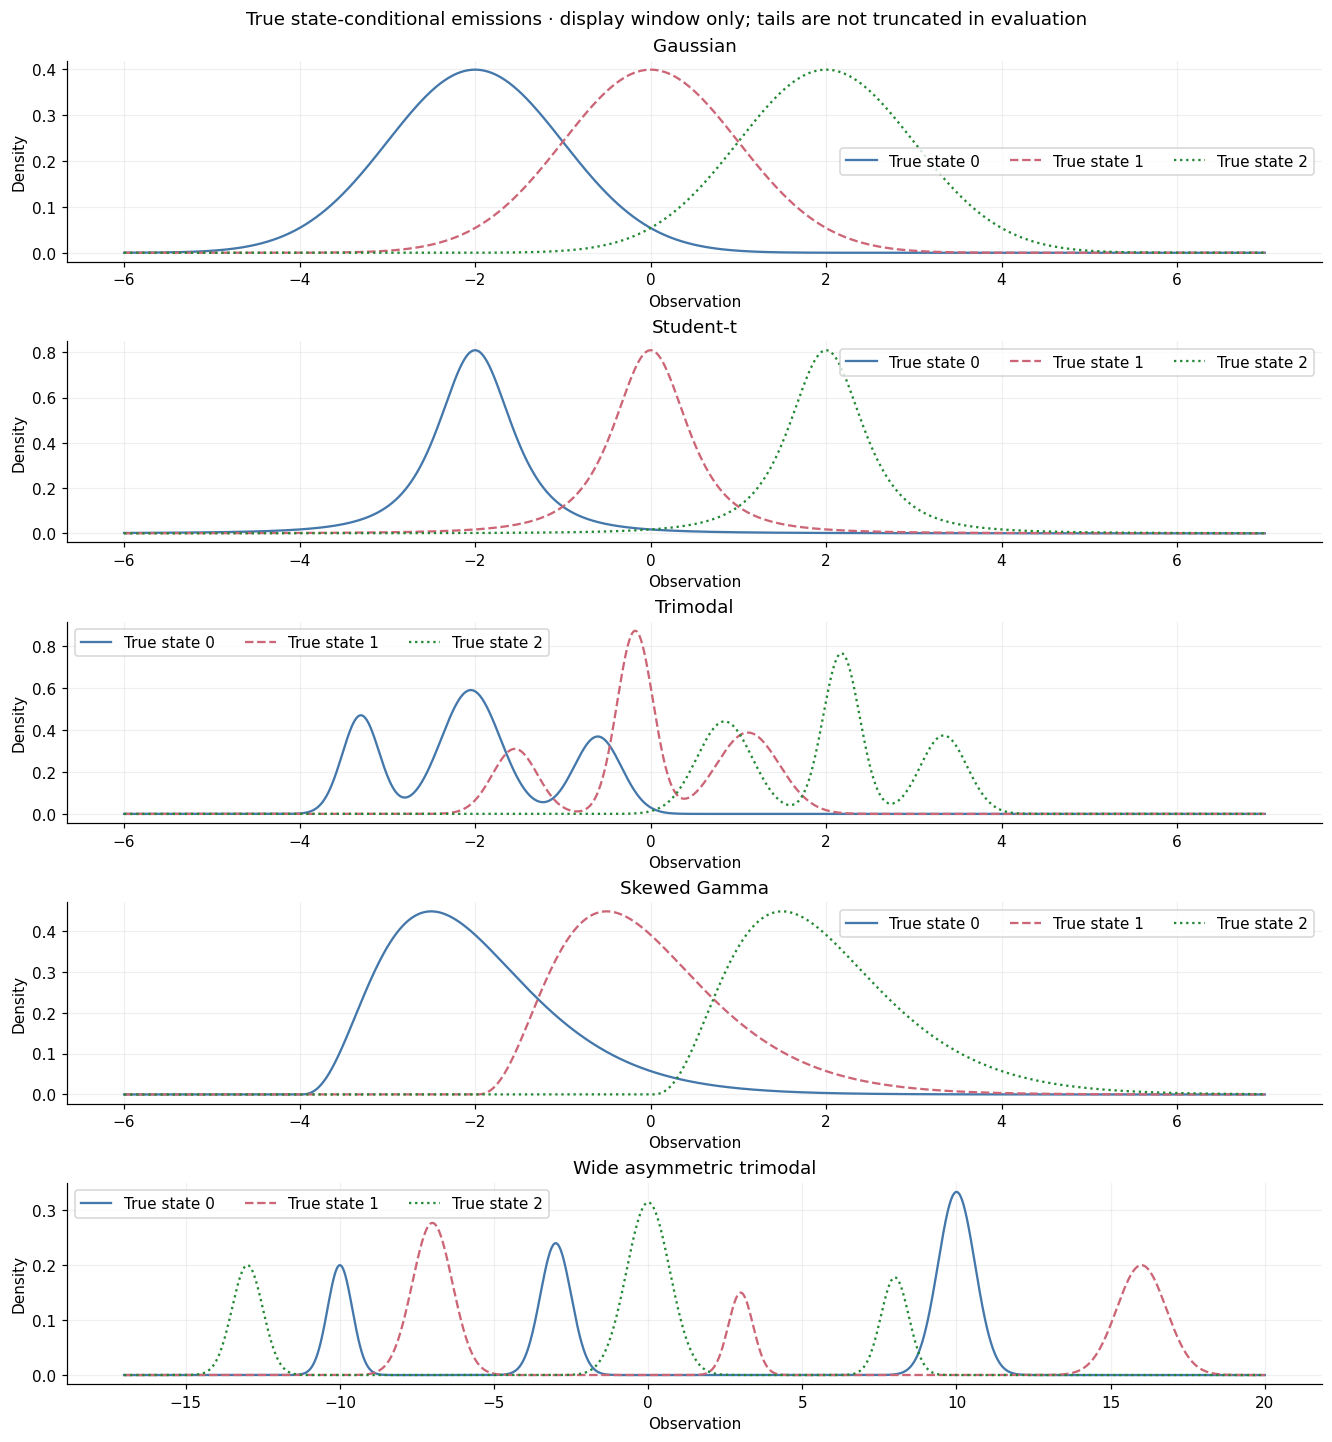

In [15]:
fig, axes = plt.subplots(len(CONFIG.families), 1, figsize=(12, 2.6 * len(CONFIG.families)),
                         squeeze=False, layout="constrained")
for ax, family in zip(axes.flat, CONFIG.families):
    grid = np.linspace(-17, 20, 3_000) if family == WIDE_FAMILY else np.linspace(-6, 7, 2_400)
    for k in STATES:
        ax.plot(grid, np.exp(true_log_density(family, k, grid)), color=STATE_COLORS[k],
                linestyle=["-", "--", ":"][k], label=f"True state {k}")
    ax.set(title=family, xlabel="Observation", ylabel="Density")
    ax.legend(ncol=3)
fig.suptitle("True state-conditional emissions · display window only; tails are not truncated in evaluation")
plt.show()

## 3. Fit both models, evaluate, and save raw artifacts

This is the expensive cell. Failures are recorded rather than silently dropped; comparison plots later require a successful fit/evaluation from **both** models for each family/size/replicate. Saved artifacts include all attempt histories and warnings, per-replicate metrics, per-state metrics, confusion counts, aligned parameters, shared datasets, and a settings/source-hash manifest. Replicate 0 at the largest training size is retained for illustrative density and decoding plots, regardless of its scores.

A unique run directory is created after fitting, before plotting. The existing Gaussian experiment artifacts are not used or overwritten. If the kernel is interrupted during fitting, this cell has not yet exported its results.

In [16]:
run = run_experiment(CONFIG, datasets)
run_dir = save_artifacts(project_root, CONFIG, datasets, coverage, run)
results, attempts = run["results"], run["attempts"]
assert len(attempts) == attempt_count
assert len(results) == attempt_count // CONFIG.n_starts
print(f"Saved raw artifacts to {run_dir}")

def show_and_save(fig, name):
    fig.savefig(run_dir / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()

Gaussian | N=1,000 | rep=00 | Gaussian HMM: ok, converged=True
Gaussian | N=1,000 | rep=00 | GMM HMM: ok, converged=True
Gaussian | N=1,000 | rep=01 | Gaussian HMM: ok, converged=True
Gaussian | N=1,000 | rep=01 | GMM HMM: ok, converged=True
Gaussian | N=1,000 | rep=02 | Gaussian HMM: ok, converged=True
Gaussian | N=1,000 | rep=02 | GMM HMM: ok, converged=True
Gaussian | N=1,000 | rep=03 | Gaussian HMM: ok, converged=True
Gaussian | N=1,000 | rep=03 | GMM HMM: ok, converged=True
Gaussian | N=1,000 | rep=04 | Gaussian HMM: ok, converged=True
Gaussian | N=1,000 | rep=04 | GMM HMM: ok, converged=True
Gaussian | N=1,000 | rep=05 | Gaussian HMM: ok, converged=True
Gaussian | N=1,000 | rep=05 | GMM HMM: ok, converged=True
Gaussian | N=1,000 | rep=06 | Gaussian HMM: ok, converged=True
Gaussian | N=1,000 | rep=06 | GMM HMM: ok, converged=False
Gaussian | N=1,000 | rep=07 | Gaussian HMM: ok, converged=True
Gaussian | N=1,000 | rep=07 | GMM HMM: ok, converged=True
Gaussian | N=1,000 | rep=08 | G

## 4. Metrics and comparison population

All classification metrics score the **aligned test Viterbi states**. Values lie in $[0,1]$ except MCC and ARI, which can be negative.

| Metric | Interpretation |
|---|---|
| Precision / recall / F1 per state | False-positive control / state coverage / their harmonic mean |
| Macro precision / recall / F1 | Equal weight for each of the three true states; primary classification comparison |
| Weighted precision / recall / F1 | Weighted by true test-state support; common states contribute more |
| Balanced accuracy | Mean per-state recall; equals macro recall here |
| Accuracy / MCC / ARI / NMI | Overall hard-label recovery; MCC adjusts for marginal counts; ARI and NMI ignore label permutations |
| Switch precision / recall / F1 | Whether $z_t\ne z_{t-1}$ occurs at the exact correct time; no tolerance window |
| State log loss / Brier score | Quality of aligned smoothed posterior probabilities; lower is better |
| Test NLL per observation | Held-out sequence negative log likelihood per point, in nats; lower is better; compare models **within** a family |
| Emission KL | Equal-state mean of $D_{KL}(p_{true}\Vert p_{fit})$; lower is better |
| Transition / mean / variance RMSE | Recovery of transition probabilities and full state-emission moments; lower is better |
| Fit time / total fit time | Selected start / all starts for that model and replicate, excluding evaluation and plots |

Undefined precision/F1 (no predictions for a state) and undefined switch scores use `zero_division=0`; state support and switch rates are retained. Micro scores would duplicate multiclass accuracy, so are omitted. State log loss uses the reference's float64-epsilon floor; capped and stored-zero fractions are reported. Brier is the mean **sum over states** of squared probability errors, with range $[0,2]$.

For GMM moment recovery, use the whole mixture:

$$
\bar\mu_k=\sum_m w_{km}\mu_{km},\qquad
\operatorname{Var}(X\mid k)=\sum_m w_{km}\left[\sigma_{km}^2+(\mu_{km}-\bar\mu_k)^2\right].
$$

Mixture components are not individually aligned because their order is arbitrary. Quadrature integrates each true mixture component in its standardized coordinate to resolve narrow, separated modes; estimated integration errors and warnings remain visible.

In [17]:
paired = paired_results(results)
expected_groups = pd.MultiIndex.from_product(
    [CONFIG.families, CONFIG.train_sizes, MODEL_NAMES], names=["family", "n_train", "model"])
coverage_summary = results.assign(success=results.evaluation_status.eq("ok")).groupby(
    ["family", "n_train", "model"]).agg(evaluations=("success", "size"), successful=("success", "sum"))
coverage_summary = coverage_summary.reindex(expected_groups)
paired_counts = paired.groupby(["family", "n_train", "model"]).size().rename("complete_pairs")
coverage_summary = coverage_summary.join(paired_counts).fillna({"complete_pairs": 0})
display(coverage_summary.astype(int))
coverage_summary.to_csv(run_dir / "comparison_coverage.csv")
if paired.empty:
    raise RuntimeError(f"No successful model pairs. Inspect results/attempts in {run_dir} before plotting.")

summary = paired.groupby(["family", "n_train", "model"])[SUMMARY_METRICS].agg(["mean", "std", "count"])
summary.to_csv(run_dir / "paired_metric_summary.csv")
display(paired.groupby(["family", "n_train", "model"])[[
    "aligned_accuracy", "precision_macro", "recall_macro", "f1_macro",
    "balanced_accuracy", "mcc", "f1_weighted", "test_nll", "emission_kl"
]].mean().round(4))

evaluations  successful  \
family                   n_train model                                   
Gaussian                 1000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         5000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         20000   Gaussian HMM           10          10   
                                 GMM HMM                10          10   
Student-t                1000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         5000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         20000   Gaussian HMM           10          10   
                                 GMM HMM                10          10   
Trimodal                 1000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         5000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         20000   Gaussian HMM           10          10   
                                 GMM HMM                10          10   
Skewed Gamma             1000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         5000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         20000   Gaussian HMM           10          10   
                                 GMM HMM                10          10   
Wide asymmetric trimodal 1000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         5000    Gaussian HMM           10          10   
                                 GMM HMM                10          10   
                         20000   Gaussian HMM           10          10   
                                 GMM HMM                10          10   

                                               complete_pairs  
family                   n_train model                         
Gaussian                 1000    Gaussian HMM              10  
                                 GMM HMM                   10  
                         5000    Gaussian HMM              10  
                                 GMM HMM                   10  
                         20000   Gaussian HMM              10  
                                 GMM HMM                   10  
Student-t                1000    Gaussian HMM              10  
                                 GMM HMM                   10  
                         5000    Gaussian HMM              10  
                                 GMM HMM                   10  
                         20000   Gaussian HMM              10  
                                 GMM HMM                   10  
Trimodal                 1000    Gaussian HMM              10  
                                 GMM HMM                   10  
                         5000    Gaussian HMM              10  
                                 GMM HMM                   10  
                         20000   Gaussian HMM              10  
                                 GMM HMM                   10  
Skewed Gamma             1000    Gaussian HMM              10  
                                 GMM HMM                   10  
                         5000    Gaussian HMM              10  
                                 GMM HMM                   10  
                         20000   Gaussian HMM              10  
                                 GMM HMM                   10  
Wide asymmetri

aligned_accuracy  \
family                   n_train model                            
Gaussian                 1000    GMM HMM                 0.9371   
                                 Gaussian HMM            0.9393   
                         5000    GMM HMM                 0.9398   
                                 Gaussian HMM            0.9400   
                         20000   GMM HMM                 0.9405   
                                 Gaussian HMM            0.9400   
Skewed Gamma             1000    GMM HMM                 0.9506   
                                 Gaussian HMM            0.9246   
                         5000    GMM HMM                 0.9545   
                                 Gaussian HMM            0.9323   
                         20000   GMM HMM                 0.9553   
                                 Gaussian HMM            0.9331   
Student-t                1000    GMM HMM                 0.9711   
                                 Gaussian HMM            0.9176   
                         5000    GMM HMM                 0.9739   
                                 Gaussian HMM            0.9100   
                         20000   GMM HMM                 0.9743   
                                 Gaussian HMM            0.8791   
Trimodal                 1000    GMM HMM                 0.9587   
                                 Gaussian HMM            0.9320   
                         5000    GMM HMM                 0.9592   
                                 Gaussian HMM            0.9332   
                         20000   GMM HMM                 0.9590   
                                 Gaussian HMM            0.9339   
Wide asymmetric trimodal 1000    GMM HMM                 0.9959   
                                 Gaussian HMM            0.5397   
                         5000    GMM HMM                 0.9965   
                                 Gaussian HMM            0.5102   
                         20000   GMM HMM                 0.9792   
                                 Gaussian HMM            0.5297   

                                               precision_macro  recall_macro  \
family                   n_train model                                         
Gaussian                 1000    GMM HMM                0.9369        0.9366   
                                 Gaussian HMM           0.9389        0.9389   
                         5000    GMM HMM                0.9397        0.9393   
                                 Gaussian HMM           0.9398        0.9395   
                         20000   GMM HMM                0.9402        0.9400   
                                 Gaussian HMM           0.9398        0.9395   
Skewed Gamma             1000    GMM HMM                0.9507        0.9499   
                                 Gaussian HMM           0.9267        0.9241   
                         5000    GMM HMM                0.9545        0.9540   
                                 Gaussian HMM           0.9329        0.9319   
                         20000   GMM HMM                0.9552        0.9548   
                                 Gaussian HMM           0.9337        0.9326   
Student-t                1000    GMM HMM                0.9710        0.9707   
                                 Gaussian HMM           0.9098        0.9174   
                         5000    GMM HMM                0.9737        0.9736   
                                 Gaussian HMM           0.9061        0.9106   
                         20000   GMM HMM                0.9741        0.9741   
                                 Gaussian HMM           0.8652        0.8764   
Trimodal                 1000    GMM HMM                0.9586        0.9584   
                                 Gaussian HMM           0.9322        0.9315   
                         5000    GMM HMM                0.9588        0.9589   
                                 Gaussian HMM           0.9332

### Classification learning curves

Curves use the same successful replicate pairs for both models. Error bars show **one sample standard deviation across replicates**. Training sizes within a replicate reuse observations and therefore are correlated.

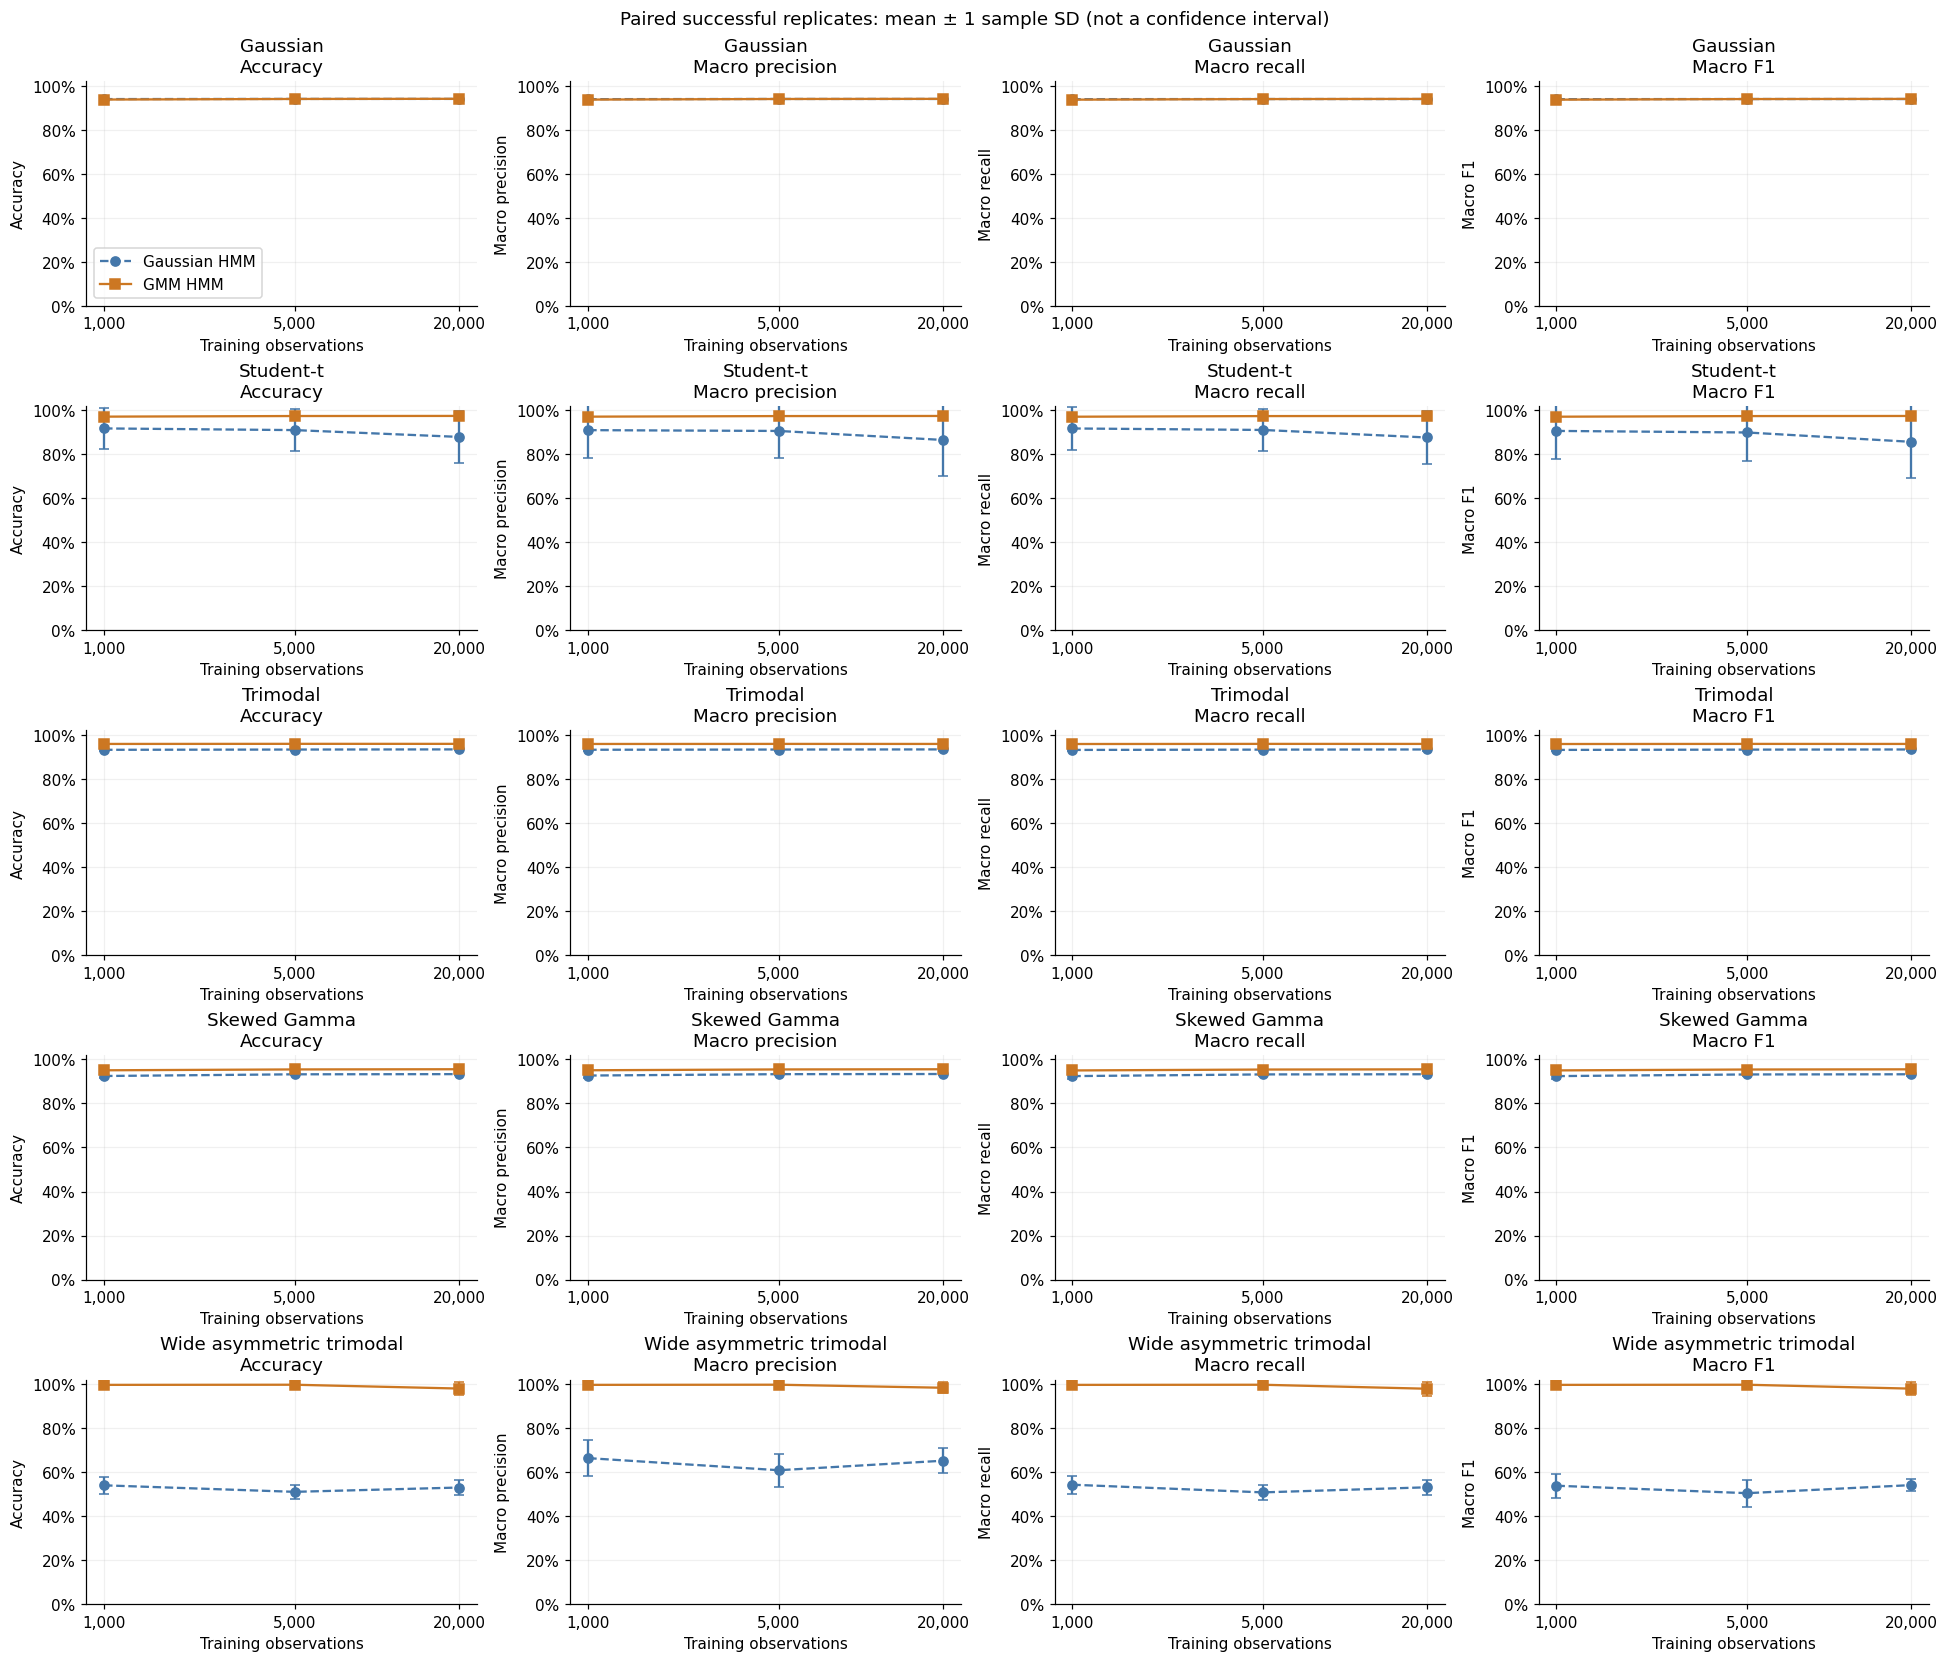

In [27]:
fig = plot_learning_curves(CONFIG, paired, [
    ("aligned_accuracy", "Accuracy", True),
    ("precision_macro", "Macro precision", True),
    ("recall_macro", "Macro recall", True),
    ("f1_macro", "Macro F1", True),
])
show_and_save(fig, "classification_learning_curves")

### Density, probability, and transition recovery

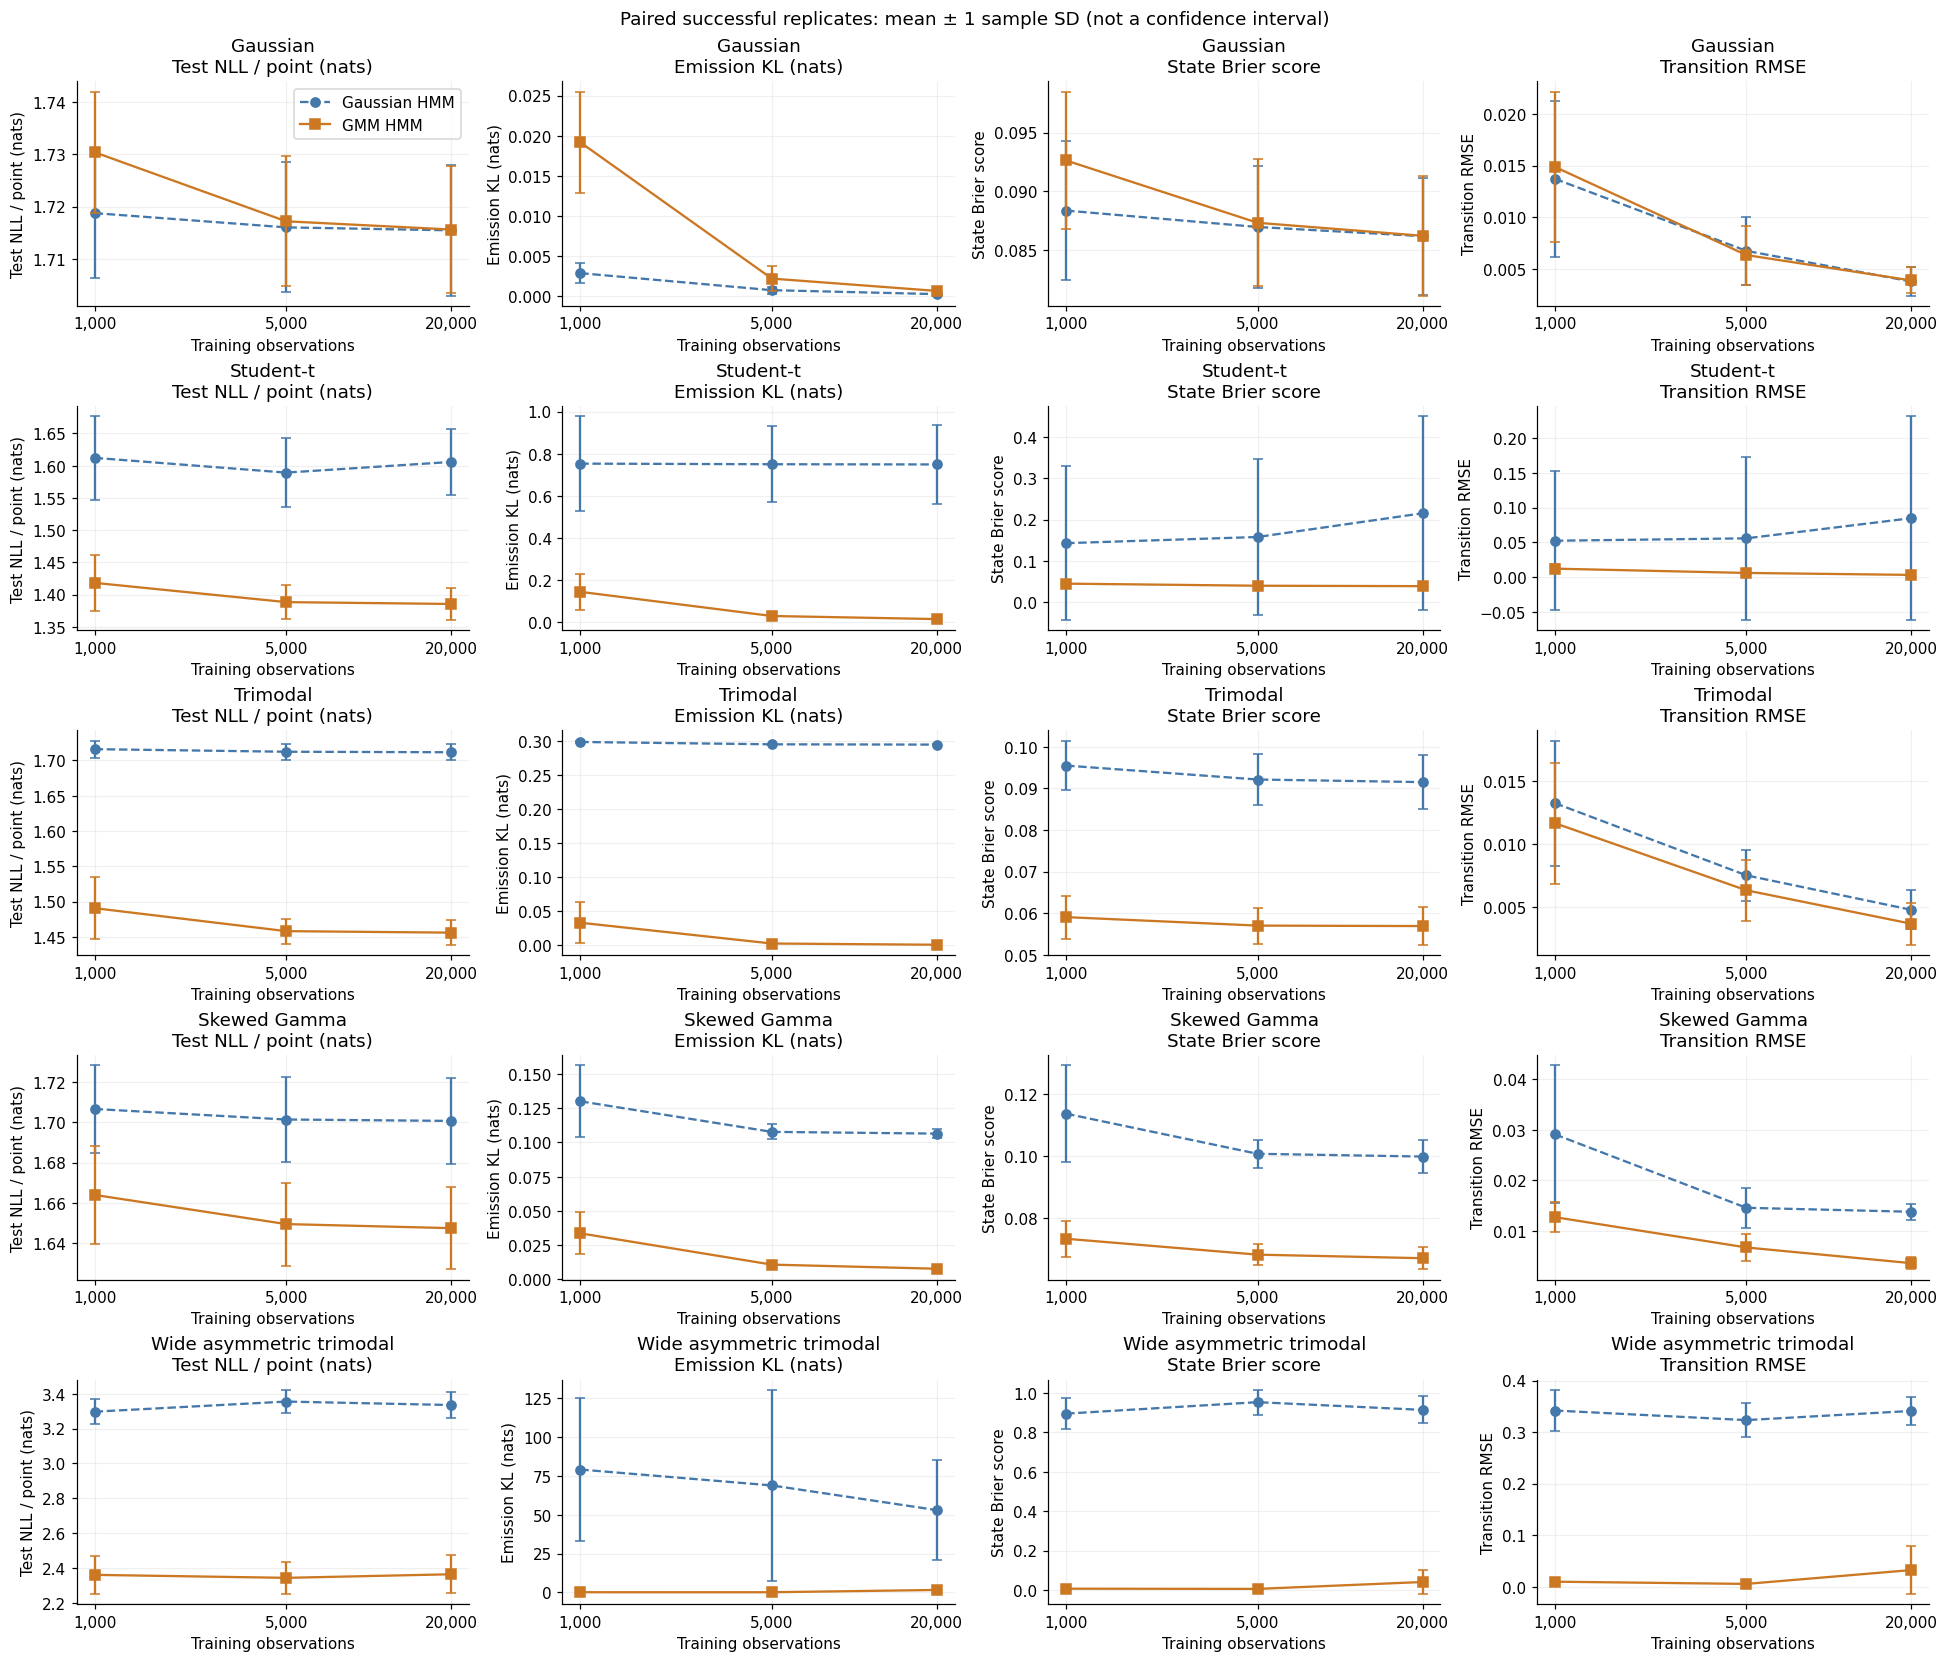

In [28]:
fig = plot_learning_curves(CONFIG, paired, [
    ("test_nll", "Test NLL / point (nats)", False),
    ("emission_kl", "Emission KL (nats)", False),
    ("state_brier_score", "State Brier score", False),
    ("transition_rmse", "Transition RMSE", False),
])
show_and_save(fig, "recovery_learning_curves")

### Paired GMM minus Gaussian differences

Compute differences within each replicate before averaging. Intervals are **95% percentile bootstrap intervals for the mean paired difference**, resampling independent replicates (2,000 draws by default). They are exploratory, unadjusted for multiple metrics/families, and unreliable with very few replicates. With one pair, only the point estimate is shown. They quantify replicate variation.

Positive differences favor GMM for F1; negative differences favor GMM for NLL, KL, and runtime. The table includes every training size; the figure uses the largest size.

,family,n_train,metric,n_pairs,mean_delta,ci_low,ci_high
0,Gaussian,1000,f1_macro,10,-0.00217,-0.00429,-0.00040
1,Gaussian,1000,test_nll,10,0.01161,0.00852,0.01458
2,Gaussian,1000,emission_kl,10,0.01631,0.01298,0.01946
3,Gaussian,1000,total_fit_seconds,10,65.33668,44.65319,90.64041
4,Gaussian,5000,f1_macro,10,-0.00017,-0.00106,0.00065
5,Gaussian,5000,test_nll,10,0.00116,0.00071,0.00168
6,Gaussian,5000,emission_kl,10,0.00145,0.00082,0.00225
7,Gaussian,5000,total_fit_seconds,10,53.98325,36.71131,72.78214
8,Gaussian,20000,f1_macro,10,0.00045,-0.00017,0.00096
9,Gaussian,20000,test_nll,10,0.00016,-0.00019,0.00048


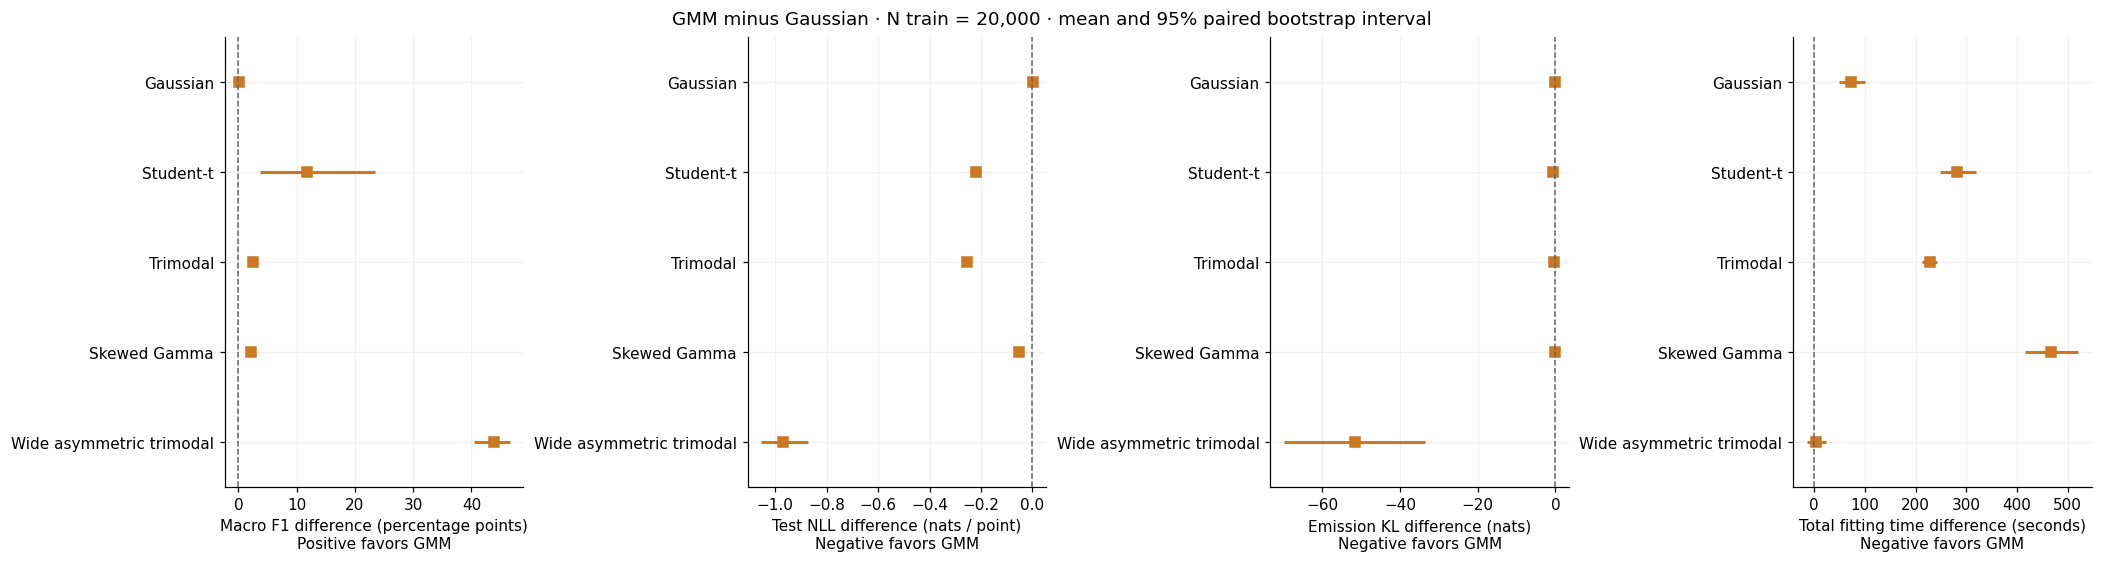

In [20]:
DELTA_METRICS = ["f1_macro", "test_nll", "emission_kl", "total_fit_seconds"]
deltas = paired_differences(CONFIG, paired, DELTA_METRICS)
deltas.to_csv(run_dir / "paired_differences.csv", index=False)
display(deltas.round(5))

fig, axes = plt.subplots(1, 4, figsize=(19, 5), layout="constrained")
for ax, metric, label in zip(axes, DELTA_METRICS, [
    "Macro F1 difference (percentage points)\nPositive favors GMM",
    "Test NLL difference (nats / point)\nNegative favors GMM",
    "Emission KL difference (nats)\nNegative favors GMM",
    "Total fitting time difference (seconds)\nNegative favors GMM",
]):
    part = deltas[(deltas.metric == metric) & (deltas.n_train == max(CONFIG.train_sizes))].set_index("family")
    scale = 100 if metric == "f1_macro" else 1
    for position, family in enumerate(CONFIG.families):
        if family not in part.index:
            ax.text(.02, position, "No pairs", transform=ax.get_yaxis_transform(), va="center")
            continue
        row = part.loc[family]
        if np.isfinite(row.ci_low):
            ax.hlines(position, scale * row.ci_low, scale * row.ci_high, color=MODEL_COLORS["GMM HMM"], linewidth=2)
        ax.plot(scale * row.mean_delta, position, "s", color=MODEL_COLORS["GMM HMM"])
    ax.axvline(0, color=".4", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(CONFIG.families)), CONFIG.families)
    ax.set(xlabel=label, ylim=(len(CONFIG.families) - .5, -.5))
fig.suptitle(f"GMM minus Gaussian · N train = {max(CONFIG.train_sizes):,} · mean and 95% paired bootstrap interval")
show_and_save(fig, "paired_model_differences")

## Confusion matrices and per-state performance

Choose `CONFUSION_N` from the configured training sizes. Both models pool the **same complete replicate pairs**. Each tile shows the count and percentage of that true state's observations; rows are true states and columns are predicted states. Colors use the same 0–100% scale throughout. Confusion counts are exported for **every** training size.

The classification report below averages each metric over replicates; mean support is per replicate. Pooled confusion percentages weight replicates by state support and can differ slightly from the mean per-replicate recall.

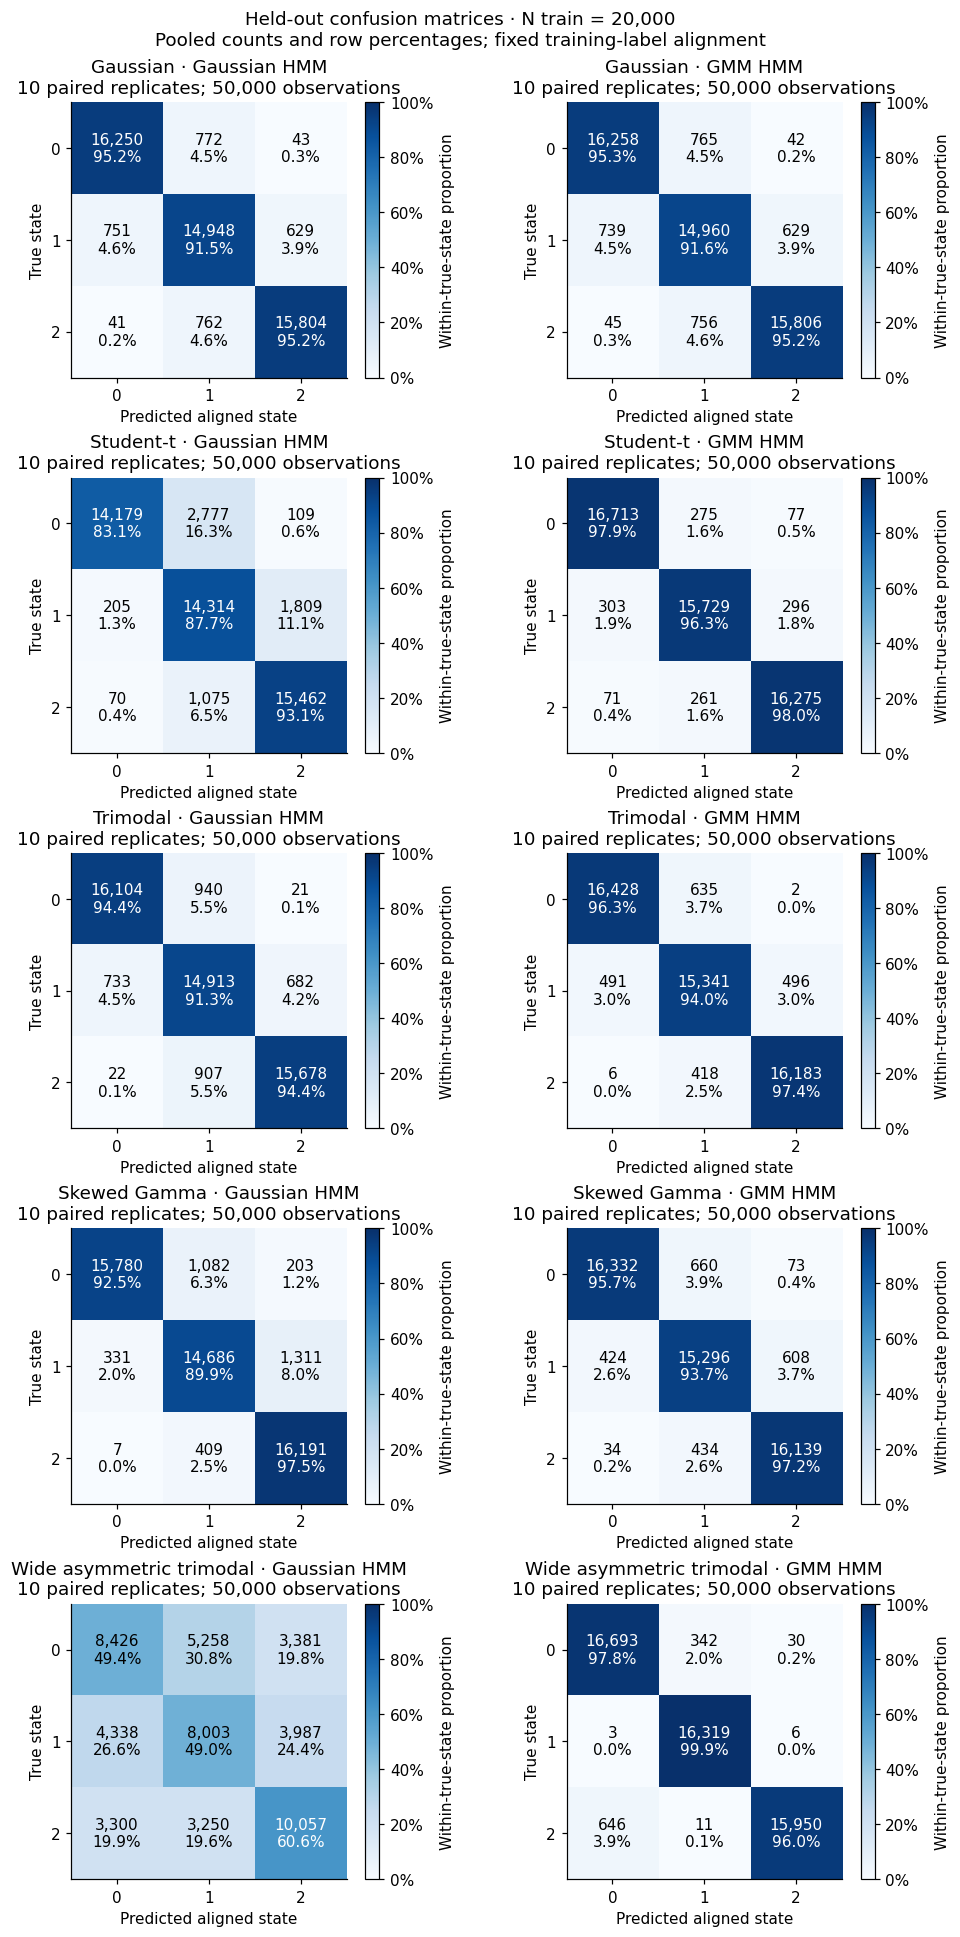

precision  recall      f1  \
family                   model        state                              
Gaussian                 GMM HMM      0         0.9538  0.9526  0.9531   
                                      1         0.9077  0.9160  0.9117   
                                      2         0.9592  0.9514  0.9552   
                         Gaussian HMM 0         0.9533  0.9521  0.9527   
                                      1         0.9070  0.9152  0.9109   
                                      2         0.9592  0.9512  0.9552   
Skewed Gamma             GMM HMM      0         0.9729  0.9567  0.9647   
                                      1         0.9331  0.9363  0.9347   
                                      2         0.9596  0.9714  0.9655   
                         Gaussian HMM 0         0.9791  0.9243  0.9509   
                                      1         0.9076  0.8988  0.9031   
                                      2         0.9143  0.9749  0.9436   
Student-t                GMM HMM      0         0.9780  0.9794  0.9787   
                                      1         0.9669  0.9632  0.9650   
                                      2         0.9774  0.9799  0.9786   
                         Gaussian HMM 0         0.9093  0.8270  0.8564   
                                      1         0.7576  0.8711  0.7938   
                                      2         0.9287  0.9310  0.9201   
Trimodal                 GMM HMM      0         0.9707  0.9626  0.9666   
                                      1         0.9355  0.9392  0.9374   
                                      2         0.9699  0.9746  0.9722   
                         Gaussian HMM 0         0.9553  0.9435  0.9494   
                                      1         0.8894  0.9129  0.9009   
                                      2         0.9567  0.9441  0.9503   
Wide asymmetric trimodal GMM HMM      0         0.9688  0.9785  0.9715   
                                      1         0.9817  0.9994  0.9897   
                                      2         0.9978  0.9571  0.9752   
                         Gaussian HMM 0         0.5560  0.4939  0.5153   
                                      1         0.6306  0.4911  0.5009   
                                      2         0.7679  0.6075  0.6062   

                                             support  
family                   model        state           
Gaussian                 GMM HMM      0       1706.5  
                                      1       1632.8  
                                      2       1660.7  
                         Gaussian HMM 0       1706.5  
                                      1       1632.8  
                                      2       1660.7  
Skewed Gamma             GMM HMM      0       1706.5  
                                      1       1632.8  
                                      2       1660.7  
                         Gaussian HMM 0       1706.5  
                                      1       1632.8  
                                      2       1660.7  
Student-t                GMM HMM      0       1706.5  
                                      1       1632.8  
                                      2       1660.7  
                         Gaussian HMM 0       1706.5  
                                      1       1632.8  
                                      2       1660.7  
Trimodal                 GMM HMM      0       1706.5  
                                      1       1632.8  
                                      2       1660.7  
                         Gaussian HMM 0       1706.5  
                                      1       1632.8  
                                      2       1660.7  
Wide asymmetric trimodal GMM HMM      0       1706.5  
                                      1       1632.8  
                                      2       1660.7  
                         Gaussian HMM 0       1706.5  
                          

In [21]:
CONFUSION_N = max(CONFIG.train_sizes)
fig = plot_confusions(CONFIG, run["confusion"], paired, CONFUSION_N)
show_and_save(fig, f"confusion_matrices_n{CONFUSION_N}")

paired_per_state = run["per_state"].merge(paired[PAIR_KEYS + ["model"]],
                                        on=PAIR_KEYS + ["model"], validate="many_to_one")
state_summary = paired_per_state.groupby(["family", "n_train", "model", "state"])[
    ["precision", "recall", "f1", "support"]].agg(["mean", "std", "count"])
state_summary.to_csv(run_dir / "per_state_summary.csv")
display(paired_per_state[paired_per_state.n_train == CONFUSION_N].groupby(
    ["family", "model", "state"])[["precision", "recall", "f1", "support"]].mean().round(4))

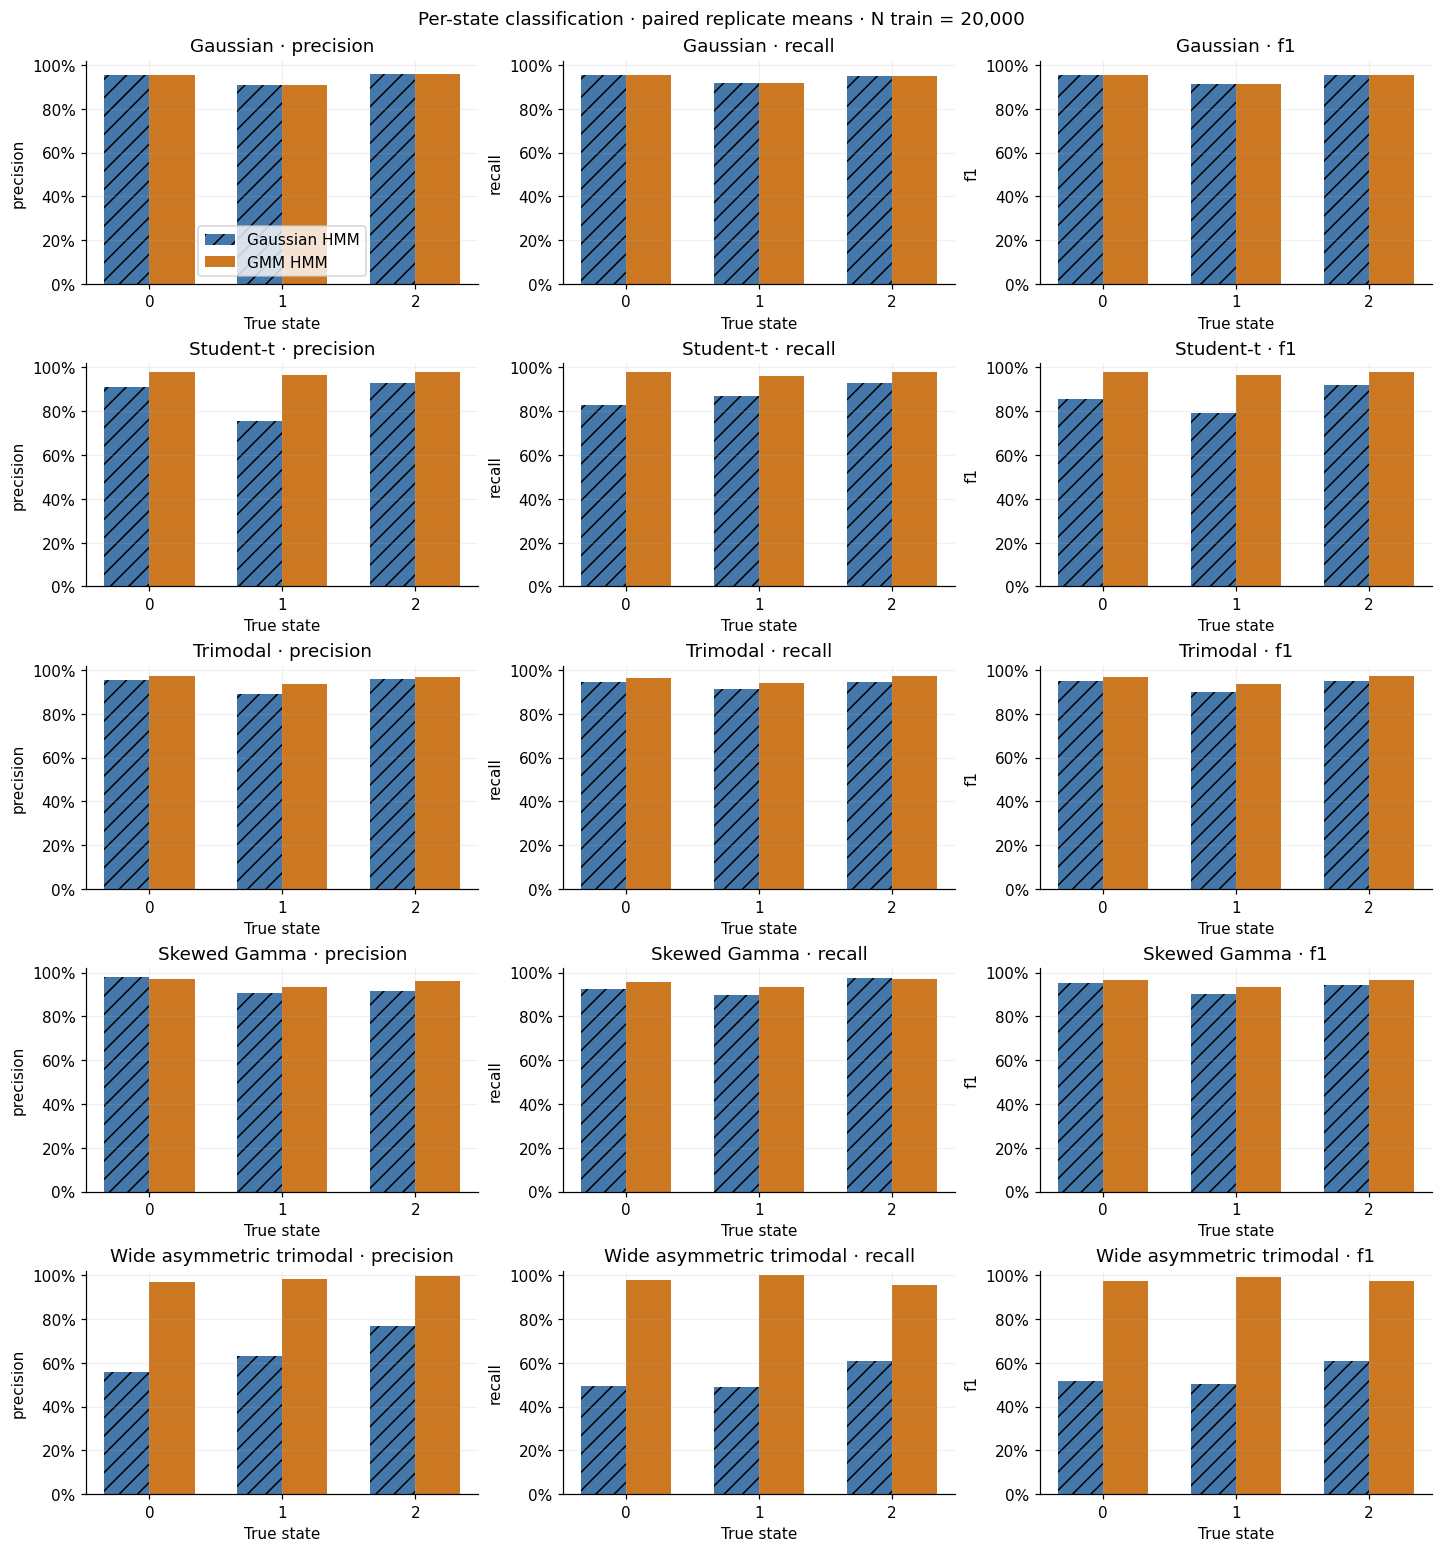

In [22]:
fig, axes = plt.subplots(len(CONFIG.families), 3, figsize=(13, 2.8 * len(CONFIG.families)),
                         squeeze=False, layout="constrained")
for row, family in enumerate(CONFIG.families):
    for column, metric in enumerate(["precision", "recall", "f1"]):
        ax = axes[row, column]
        for model_index, model in enumerate(MODEL_NAMES):
            part = paired_per_state[(paired_per_state.family == family) &
                                    (paired_per_state.model == model) & (paired_per_state.n_train == CONFUSION_N)]
            values = part.groupby("state")[metric].mean().reindex(STATES)
            ax.bar(STATES + (model_index - .5) * .34, values, width=.34,
                   color=MODEL_COLORS[model], hatch="//" if model_index == 0 else "", label=model)
        ax.set(title=f"{family} · {metric}", xlabel="True state", ylabel=metric, ylim=(0, 1.02))
        ax.set_xticks(STATES)
        ax.yaxis.set_major_formatter(PercentFormatter(1))
axes[0, 0].legend()
fig.suptitle(f"Per-state classification · paired replicate means · N train = {CONFUSION_N:,}")
show_and_save(fig, "per_state_classification")

## Illustrative fitted emissions and decoded sequence

These figures always use **replicate 0 at the largest training size**, not the best test outcome. The density overlay compares full state-conditional mixtures, without aligning individual components. 

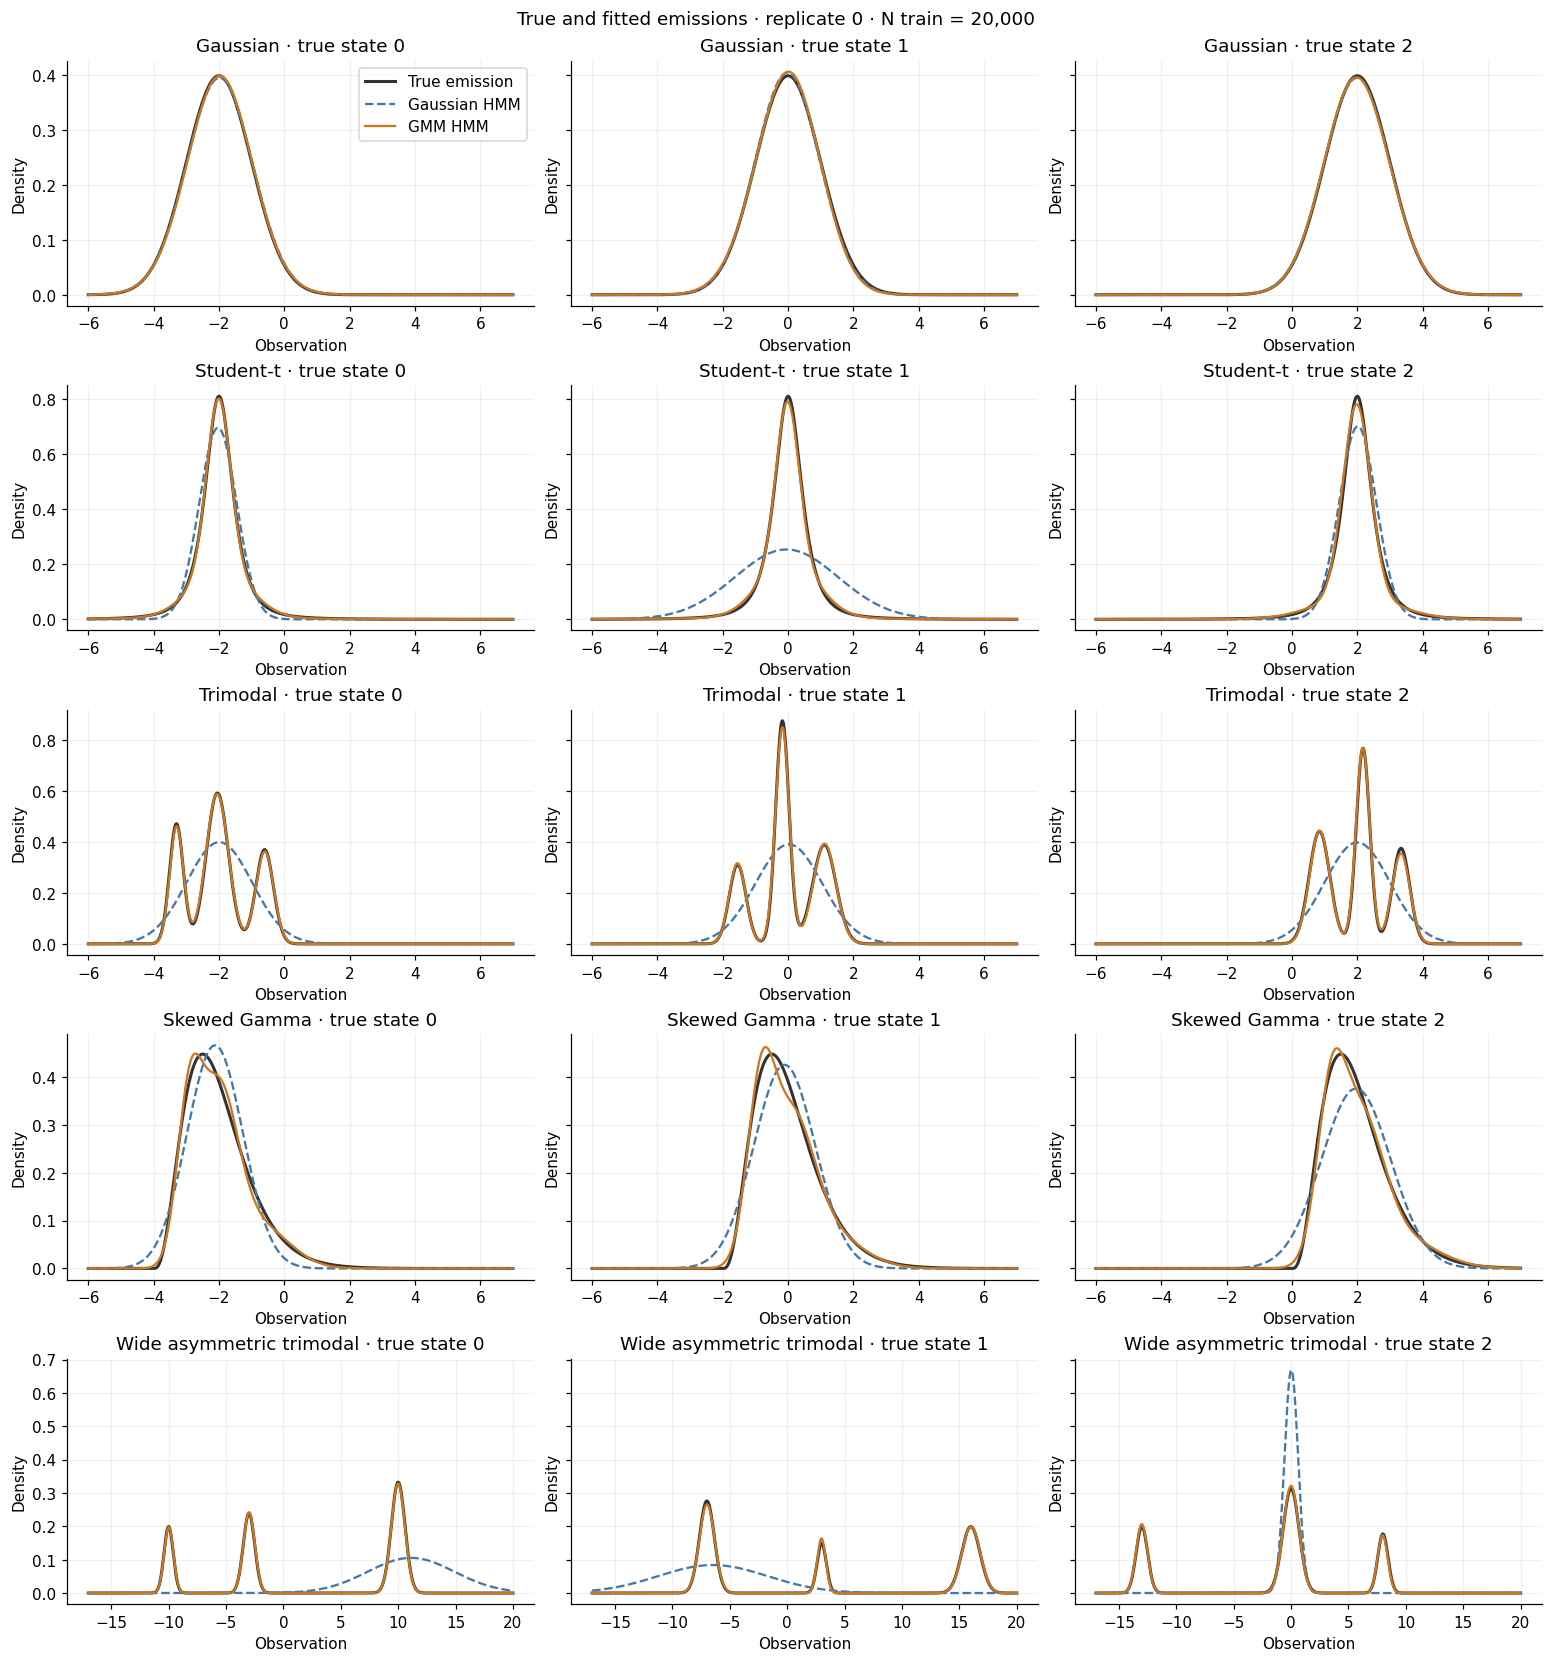

In [23]:
fig, axes = plt.subplots(len(CONFIG.families), 3, figsize=(14, 3 * len(CONFIG.families)),
                         squeeze=False, sharey="row", layout="constrained")
for row, family in enumerate(CONFIG.families):
    grid = np.linspace(-17, 20, 3_000) if family == WIDE_FAMILY else np.linspace(-6, 7, 2_400)
    for k, ax in enumerate(axes[row]):
        ax.plot(grid, np.exp(true_log_density(family, k, grid)), color=".2", linewidth=2, label="True emission")
        missing = []
        for model_name in MODEL_NAMES:
            example = run["examples"].get((family, model_name))
            if example is None:
                missing.append(model_name)
                continue
            order = np.argsort(example["evaluation"].state_mapping)
            log_density = example["model"].emission.log_prob(grid[:, None])[:, order[k]]
            ax.plot(grid, np.exp(log_density), color=MODEL_COLORS[model_name],
                    linestyle=MODEL_STYLES[model_name][1], label=model_name)
        if missing:
            ax.text(.03, .95, "Unavailable: " + ", ".join(missing), transform=ax.transAxes, va="top", fontsize=8)
        ax.set(title=f"{family} · true state {k}", xlabel="Observation", ylabel="Density")
axes[0, 0].legend()
fig.suptitle(f"True and fitted emissions · replicate 0 · N train = {max(CONFIG.train_sizes):,}")
show_and_save(fig, "fitted_emission_densities")

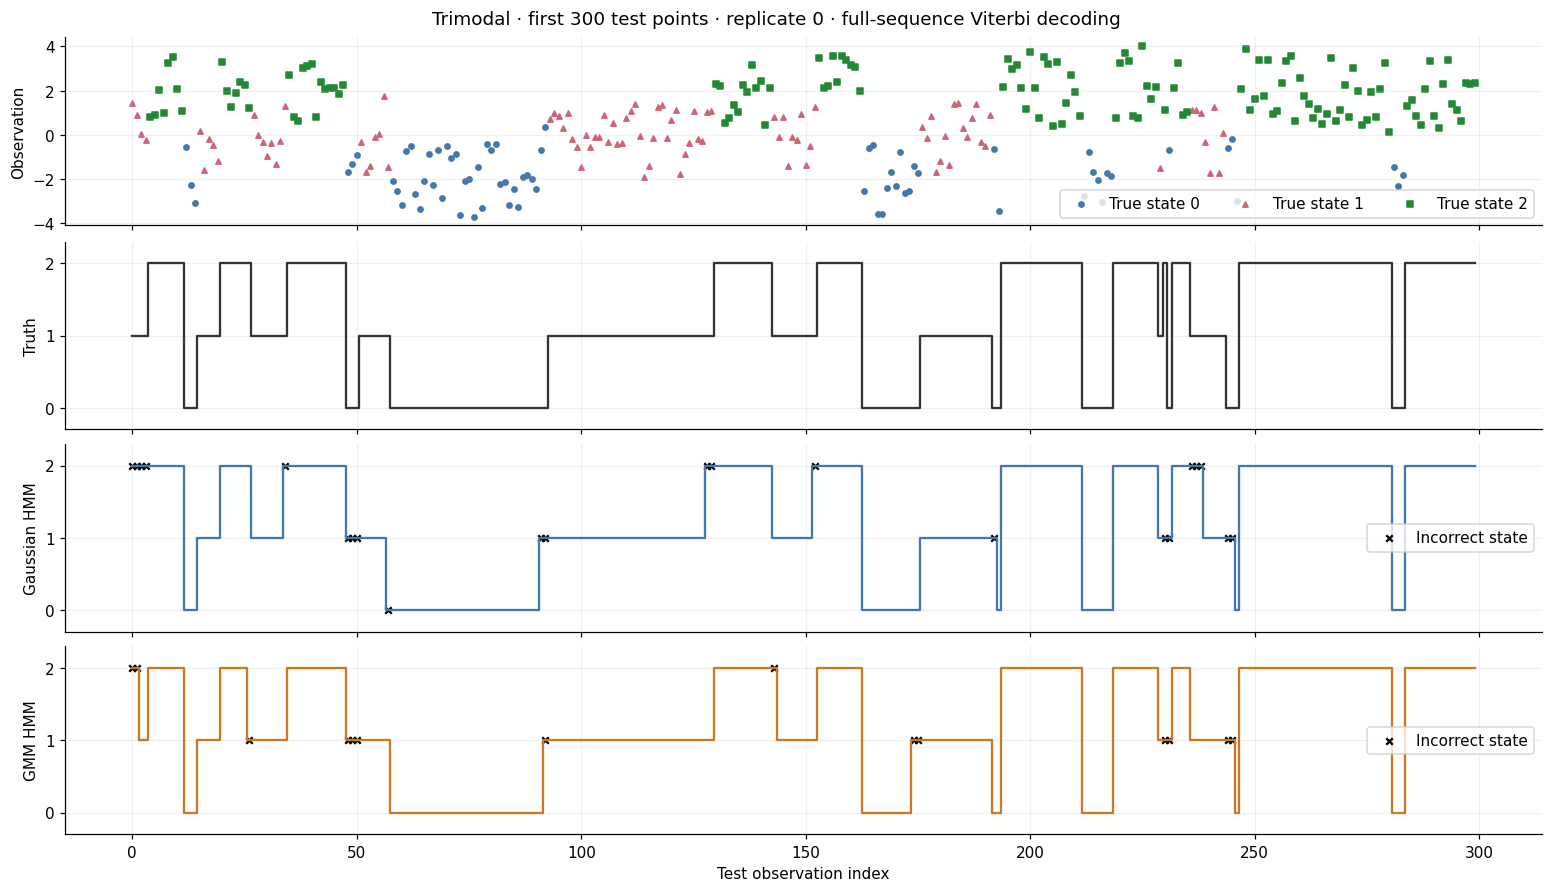

In [24]:
EXAMPLE_FAMILY = "Trimodal"   # Can also use WIDE_FAMILY when include_wide=True.
ZOOM_POINTS = min(300, CONFIG.n_test)
frame = datasets[0, EXAMPLE_FAMILY]["test"].iloc[:ZOOM_POINTS]
positions = np.arange(ZOOM_POINTS)
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True, layout="constrained")
for k in STATES:
    mask = frame.state.to_numpy() == k
    axes[0].scatter(positions[mask], frame.x.to_numpy()[mask], s=12,
                    color=STATE_COLORS[k], marker=["o", "^", "s"][k], label=f"True state {k}")
axes[0].set_ylabel("Observation")
axes[0].legend(ncol=3)
axes[1].step(positions, frame.state, where="mid", color=".2")
axes[1].set_ylabel("Truth")
for ax, model_name in zip(axes[2:], MODEL_NAMES):
    example = run["examples"].get((EXAMPLE_FAMILY, model_name))
    if example is None:
        ax.text(.5, .5, "Fit/evaluation unavailable", transform=ax.transAxes, ha="center")
    else:
        predicted = example["evaluation"].aligned_states[0][:ZOOM_POINTS]
        ax.step(positions, predicted, where="mid", color=MODEL_COLORS[model_name])
        wrong = predicted != frame.state.to_numpy()
        ax.scatter(positions[wrong], predicted[wrong], color="black", marker="x", s=18, label="Incorrect state")
        ax.legend()
    ax.set_ylabel(model_name)
for ax in axes[1:]:
    ax.set(yticks=STATES, ylim=(-.3, 2.3))
axes[-1].set_xlabel("Test observation index")
fig.suptitle(f"{EXAMPLE_FAMILY} · first {ZOOM_POINTS} test points · replicate 0 · full-sequence Viterbi decoding")
show_and_save(fig, "example_state_decoding")

## Fit reliability, computation, and remaining diagnostics

Inspect failures, nonconvergence, likelihood decreases, posterior probability caps, and integration warnings before interpreting model differences.

In [25]:
fit_diagnostics = attempts.assign(failed=attempts.status.ne("ok")).groupby(
    ["family", "n_train", "model"]).agg(
    starts=("status", "size"), failures=("failed", "sum"), converged_starts=("converged", "sum"),
    mean_iterations=("iterations", "mean"), total_fit_seconds=("fit_seconds", "sum"),
    likelihood_decreases=("likelihood_decreases", "sum"))
selected_diagnostics = results.groupby(["family", "n_train", "model"]).agg(
    evaluations=("evaluation_status", "size"), selected_converged=("converged", "sum"))
fit_diagnostics = fit_diagnostics.join(selected_diagnostics)
fit_diagnostics.to_csv(run_dir / "fit_diagnostics.csv")
display(fit_diagnostics.round(3))
display(paired.groupby(["family", "n_train", "model"])[[
    "switch_precision", "switch_recall", "switch_f1", "true_switch_rate", "predicted_switch_rate",
    "state_log_loss", "state_log_loss_capped_fraction", "state_zero_probability_fraction",
    "mean_rmse", "variance_rmse", "kl_quad_error_max", "total_fit_seconds"
]].mean().round(6))

start_variability = attempts[attempts.status == "ok"].groupby(PAIR_KEYS + ["model"]).train_ll.agg(["min", "max"])
start_variability["range_per_observation"] = (start_variability["max"] - start_variability["min"]) / start_variability.index.get_level_values("n_train")
start_variability.to_csv(run_dir / "initialization_variability.csv")
display(start_variability.groupby(["family", "n_train", "model"])[["range_per_observation"]].mean().round(6))
for label, frame, column in [("Fit", attempts, "warnings"), ("Evaluation", results, "evaluation_warnings")]:
    if column in frame:
        messages = frame[column].explode().dropna()
        print(f"{label} warnings: {len(messages)}")
        if len(messages):
            display(messages.value_counts().head(20).to_frame("count"))
failed = results[results.evaluation_status != "ok"]
print("Evaluation outcomes:", results.evaluation_status.value_counts().to_dict())
if not failed.empty:
    display(failed.reindex(columns=PAIR_KEYS + ["model", "evaluation_status", "error"]).head(20))
print(f"All detailed failures and warnings are saved in {run_dir}")

starts  failures  \
family                   n_train model                            
Gaussian                 1000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         5000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         20000   GMM HMM          100         0   
                                 Gaussian HMM     100         0   
Skewed Gamma             1000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         5000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         20000   GMM HMM          100         0   
                                 Gaussian HMM     100         0   
Student-t                1000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         5000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         20000   GMM HMM          100         0   
                                 Gaussian HMM     100         0   
Trimodal                 1000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         5000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         20000   GMM HMM          100         0   
                                 Gaussian HMM     100         0   
Wide asymmetric trimodal 1000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         5000    GMM HMM          100         0   
                                 Gaussian HMM     100         0   
                         20000   GMM HMM          100         0   
                                 Gaussian HMM     100         0   

                                               converged_starts  \
family                   n_train model                            
Gaussian                 1000    GMM HMM                     94   
                                 Gaussian HMM               100   
                         5000    GMM HMM                    100   
                                 Gaussian HMM               100   
                         20000   GMM HMM                    100   
                                 Gaussian HMM               100   
Skewed Gamma             1000    GMM HMM                    100   
                                 Gaussian HMM               100   
                         5000    GMM HMM                    100   
                                 Gaussian HMM               100   
                         20000   GMM HMM                    100   
                                 Gaussian HMM               100   
Student-t                1000    GMM HMM                    100   
                                 Gaussian HMM               100   
                         5000    GMM HMM                    100   
                                 Gaussian HMM               100   
                         20000   GMM HMM                    100   
                                 Gaussian HMM               100   
Trimodal                 1000    GMM HMM                    100   
                                 Gaussian HMM               100   
                         5000    GMM HMM                    100   
                                 Gaussian HMM               100   
                         20000   GMM HMM                    100   
                                 Gaussian HMM               100   
Wide asymmetric trimodal 1000    GMM HMM                    100   
                                 Gaussian HMM               100   
                         5

switch_precision  \
family                   n_train model                            
Gaussian                 1000    GMM HMM               0.739014   
                                 Gaussian HMM          0.749582   
                         5000    GMM HMM               0.754903   
                                 Gaussian HMM          0.757843   
                         20000   GMM HMM               0.758153   
                                 Gaussian HMM          0.758081   
Skewed Gamma             1000    GMM HMM               0.759660   
                                 Gaussian HMM          0.634743   
                         5000    GMM HMM               0.791095   
                                 Gaussian HMM          0.675391   
                         20000   GMM HMM               0.798798   
                                 Gaussian HMM          0.679124   
Student-t                1000    GMM HMM               0.812284   
                                 Gaussian HMM          0.694975   
                         5000    GMM HMM               0.851601   
                                 Gaussian HMM          0.700917   
                         20000   GMM HMM               0.859039   
                                 Gaussian HMM          0.703843   
Trimodal                 1000    GMM HMM               0.811020   
                                 Gaussian HMM          0.731102   
                         5000    GMM HMM               0.811836   
                                 Gaussian HMM          0.734510   
                         20000   GMM HMM               0.812767   
                                 Gaussian HMM          0.734045   
Wide asymmetric trimodal 1000    GMM HMM               0.983299   
                                 Gaussian HMM          0.135425   
                         5000    GMM HMM               0.983948   
                                 Gaussian HMM          0.139339   
                         20000   GMM HMM               0.845124   
                                 Gaussian HMM          0.128993   

                                               switch_recall  switch_f1  \
family                   n_train model                                    
Gaussian                 1000    GMM HMM            0.614813   0.670675   
                                 Gaussian HMM       0.618469   0.677630   
                         5000    GMM HMM            0.614615   0.677430   
                                 Gaussian HMM       0.615951   0.679452   
                         20000   GMM HMM            0.614944   0.678989   
                                 Gaussian HMM       0.614311   0.678607   
Skewed Gamma             1000    GMM HMM            0.679267   0.716942   
                                 Gaussian HMM       0.661817   0.646612   
                         5000    GMM HMM            0.682522   0.732606   
                                 Gaussian HMM       0.657700   0.665986   
                         20000   GMM HMM            0.682673   0.736074   
                                 Gaussian HMM       0.656765   0.667532   
Student-t                1000    GMM HMM            0.800325   0.805742   
                                 Gaussian HMM       0.750769   0.718598   
                         5000    GMM HMM            0.794070   0.821701   
                                 Gaussian HMM       0.715572   0.704925   
                         20000   GMM HMM            0.790522   0.823309   
                                 Gaussian HMM       0.669741   0.685091   
Trimodal                 1000    GMM HMM            0.715575   0.760207   
                                 Gaussian HMM       0.570526   0.640605   
                         5000    GMM HMM            0.714471   0.759927   
                                 Gaussian HMM       0.567701   0.640224   
                         20000   GMM HMM            0.714068   0.760146   
                           

range_per_observation
family                   n_train model                              
Gaussian                 1000    GMM HMM                    0.005868
                                 Gaussian HMM               0.019247
                         5000    GMM HMM                    0.000778
                                 Gaussian HMM               0.011214
                         20000   GMM HMM                    0.000133
                                 Gaussian HMM               0.000001
Skewed Gamma             1000    GMM HMM                    0.004456
                                 Gaussian HMM               0.022553
                         5000    GMM HMM                    0.001889
                                 Gaussian HMM               0.040361
                         20000   GMM HMM                    0.016431
                                 Gaussian HMM               0.012073
Student-t                1000    GMM HMM                    0.073505
                                 Gaussian HMM               0.179486
                         5000    GMM HMM                    0.004874
                                 Gaussian HMM               0.097109
                         20000   GMM HMM                    0.026173
                                 Gaussian HMM               0.082350
Trimodal                 1000    GMM HMM                    0.089700
                                 Gaussian HMM               0.008244
                         5000    GMM HMM                    0.119763
                                 Gaussian HMM               0.000017
                         20000   GMM HMM                    0.110166
                                 Gaussian HMM               0.034555
Wide asymmetric trimodal 1000    GMM HMM                    0.650162
                                 Gaussian HMM               0.218642
                         5000    GMM HMM                    0.601624
                                 Gaussian HMM               0.110227
                         20000   GMM HMM                    0.653134
                                 Gaussian HMM               0.158504

Fit warnings: 0
Evaluation warnings: 0
Evaluation outcomes: {'ok': 300}
All detailed failures and warnings are saved in /Users/leoyang/Desktop/School/CSCD94/data/synthetic/gmm_synthetic_experiments/20261008T064730Z-tftjwhbr


### Reference: the best possible single-Gaussian emission KL

The Gaussian matching the true mean and variance minimizes KL from the true emission to a single Gaussian. This floor explains irreducible shape mismatch for Gaussian emissions. It is **not a lower bound for GMM**, so a GMM may go below it. It also does not imply an HMM state-recovery limit. This cell calculates and exports the floor without fitting another model.

In [26]:
floor_rows = []
for family in CONFIG.families:
    means, variances = true_moments(family)
    for k in STATES:
        value, error = emission_kl(CONFIG, family, k, np.array([1.]),
                                   np.array([means[k]]), np.array([variances[k]]))
        floor_rows.append({"family": family, "state": int(k), "gaussian_kl_floor": value, "quad_error": error})
floors = pd.DataFrame(floor_rows)
assert abs(floors[floors.family == "Gaussian"].gaussian_kl_floor.max()) < 1e-7
floors.to_csv(run_dir / "gaussian_kl_floor.csv", index=False)
comparison_kl = paired.groupby(["family", "n_train", "model"]).emission_kl.mean().rename("fitted_kl").to_frame()
comparison_kl = comparison_kl.join(floors.groupby("family").gaussian_kl_floor.mean(), on="family")
comparison_kl["kl_minus_gaussian_floor"] = comparison_kl.fitted_kl - comparison_kl.gaussian_kl_floor
comparison_kl.to_csv(run_dir / "kl_vs_gaussian_floor.csv")
display(comparison_kl.round(6))

fitted_kl  gaussian_kl_floor  \
family                   n_train model                                        
Gaussian                 1000    GMM HMM        0.019178           0.000000   
                                 Gaussian HMM   0.002866           0.000000   
                         5000    GMM HMM        0.002189           0.000000   
                                 Gaussian HMM   0.000743           0.000000   
                         20000   GMM HMM        0.000650           0.000000   
                                 Gaussian HMM   0.000252           0.000000   
Skewed Gamma             1000    GMM HMM        0.033688           0.088679   
                                 Gaussian HMM   0.130035           0.088679   
                         5000    GMM HMM        0.010852           0.088679   
                                 Gaussian HMM   0.107725           0.088679   
                         20000   GMM HMM        0.007852           0.088679   
                                 Gaussian HMM   0.106442           0.088679   
Student-t                1000    GMM HMM        0.144162           0.375897   
                                 Gaussian HMM   0.753045           0.375897   
                         5000    GMM HMM        0.029400           0.375897   
                                 Gaussian HMM   0.750133           0.375897   
                         20000   GMM HMM        0.014730           0.375897   
                                 Gaussian HMM   0.749147           0.375897   
Trimodal                 1000    GMM HMM        0.032934           0.294603   
                                 Gaussian HMM   0.298862           0.294603   
                         5000    GMM HMM        0.002320           0.294603   
                                 Gaussian HMM   0.295416           0.294603   
                         20000   GMM HMM        0.000493           0.294603   
                                 Gaussian HMM   0.294980           0.294603   
Wide asymmetric trimodal 1000    GMM HMM        0.065356           1.672370   
                                 Gaussian HMM  79.114661           1.672370   
                         5000    GMM HMM        0.047758           1.672370   
                                 Gaussian HMM  68.860875           1.672370   
                         20000   GMM HMM        1.524322           1.672370   
                                 Gaussian HMM  52.970654           1.672370   

                                               kl_minus_gaussian_floor  
family                   n_train model                                  
Gaussian                 1000    GMM HMM                      0.019178  
                                 Gaussian HMM                 0.002866  
                         5000    GMM HMM                      0.002189  
                                 Gaussian HMM                 0.000743  
                         20000   GMM HMM                      0.000650  
                                 Gaussian HMM                 0.000252  
Skewed Gamma             1000    GMM HMM                     -0.054991  
                                 Gaussian HMM                 0.041356  
                         5000    GMM HMM                     -0.077827  
                                 Gaussian HMM                 0.019045  
                         20000   GMM HMM                     -0.080827  
                                 Gaussian HMM                 0.017763  
Student-t                1000    GMM HMM                     -0.231735  
                                 Gaussian HMM                 0.377147  
                         5000    GMM HMM                     -0.346497  
                                 Gaussian HMM                 0.374236  
                         20000   GMM HMM                     -0.361167  
                                 Gaussian HMM                 0.373250  
Trimodal                 1000    GMM HMM                  